In [53]:
images = r"D:\Kì 1 2024-2025\Machine Learning\Model Final\Finallll\Dataset Images"

In [54]:
from pickle import load

with open(r"D:\Kì 1 2024-2025\Machine Learning\Model Final\Finallll\Encode\encoded_test_images.pkl", "rb") as encoded_pickle:
    encoding_test = load(encoded_pickle)

In [55]:
# Với môi ảnh mới khi test, ta sẽ bắt đầu chuỗi với 'startseq' rồi sau đó cho vào model để dự đoán từ tiếp theo. Ta thêm từ
# vừa được dự đoán vào chuỗi và tiếp tục cho đến khi gặp 'endseq' là kết thúc hoặc cho đến khi chuỗi dài 34 từ.
def greedySearch(photo):
    in_text = 'startseq'
    for i in range(max_length):
        sequence = [wordtoix[w] for w in in_text.split() if w in wordtoix]
        sequence = pad_sequences([sequence], maxlen=max_length)
        yhat = model.predict([photo,sequence], verbose=0)
        yhat = np.argmax(yhat)
        word = ixtoword[yhat]
        in_text += ' ' + word
        if word == 'endseq':
            break
    final = in_text.split()
    final = final[1:-1]
    final = ' '.join(final)
    return final

In [56]:

import os
import random
import numpy as np
import pickle
from tensorflow.keras.models import load_model, Model
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.preprocessing.sequence import pad_sequences
model_path = r"D:\Kì 1 2024-2025\Machine Learning\Model Final\Finallll\model_new.keras"
wordtoix_path = r"D:\Kì 1 2024-2025\Machine Learning\Model Final\Finallll\wordtoix.npy"
ixtoword_path = r"D:\Kì 1 2024-2025\Machine Learning\Model Final\Finallll\ixtoword.npy"

# Tải mô hình đã huấn luyện
model = load_model(model_path)
vocab_size = len(wordtoix) + 1
# Tải các tệp hỗ trợ
wordtoix = np.load(wordtoix_path, allow_pickle=True).item()
ixtoword = np.load(ixtoword_path, allow_pickle=True).item()

In [50]:
from tensorflow.keras.layers import Input, Dense, Embedding, LSTM, Add
from tensorflow.keras.models import Model

# Đầu vào ảnh (đặc trưng ảnh đã qua InceptionV3)
input1 = Input(shape=(2048,))
image_features = Dense(256, activation='relu')(input1)

# Đầu vào chuỗi từ
input2 = Input(shape=(max_length,))
sequence_features = Embedding(vocab_size, 256, mask_zero=True)(input2)
sequence_features = LSTM(256)(sequence_features)

# Kết hợp đặc trưng ảnh và chuỗi từ
decoder = Add()([image_features, sequence_features])
decoder = Dense(256, activation='relu')(decoder)
output = Dense(vocab_size, activation='softmax')(decoder)

# Tạo mô hình
model = Model(inputs=[input1, input2], outputs=output)

# Compile mô hình (nếu cần huấn luyện lại)
model.compile(loss='categorical_crossentropy', optimizer='adam')


In [51]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array, load_img
import numpy as np

# Mô hình InceptionV3 để trích xuất đặc trưng ảnh
inception_model = InceptionV3(weights='imagenet', include_top=False, pooling='avg')

def encode_image(image_path):
    img = load_img(image_path, target_size=(299, 299))
    img = img_to_array(img)
    img = preprocess_input(img)
    img = np.expand_dims(img, axis=0)
    feature = inception_model.predict(img)
    return feature  # Kết quả: vector (1, 2048)


In [52]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

def greedySearch(photo, max_length):
    in_text = 'startseq'
    for _ in range(max_length):
        # Mã hóa chuỗi hiện tại
        sequence = [wordtoix[w] for w in in_text.split() if w in wordtoix]
        sequence = pad_sequences([sequence], maxlen=max_length)

        # Dự đoán từ tiếp theo
        yhat = model.predict([photo, sequence], verbose=0)
        yhat = np.argmax(yhat)
        word = ixtoword[yhat]

        if word == 'endseq':
            break
        in_text += ' ' + word
    return in_text


In [ ]:
import os
import matplotlib.pyplot as plt

# Đường dẫn thư mục ảnh
images_dir = r"D:\Kì 1 2024-2025\Machine Learning\Model Final\Finallll\Dataset Images"
random_pics = random.sample(list(encoding_test.keys()), 10)

for pic in random_pics:
    # Đường dẫn ảnh
    file_path = os.path.join(images_dir, pic)

    if not os.path.exists(file_path):
        print(f"Không tìm thấy tệp: {file_path}")
        continue

    # Hiển thị ảnh
    x = plt.imread(file_path)
    plt.imshow(x)
    plt.show()

    # Mã hóa ảnh
    photo = encode_image(file_path)

    # Sinh chú thích
    caption = greedySearch(photo, max_length)
    print("Predicted Caption:", caption)


In [45]:
# Load the inception v3 model
model = InceptionV3(weights='imagenet')
# Create a new model, removing the last layer from inception v3
model_new = Model(model.input, model.layers[-2].output)

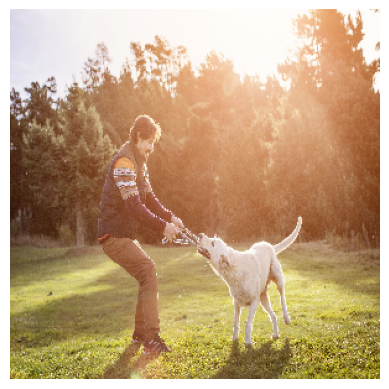

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
Predicted Caption: startseq man in white shirt is standing in the middle of the road


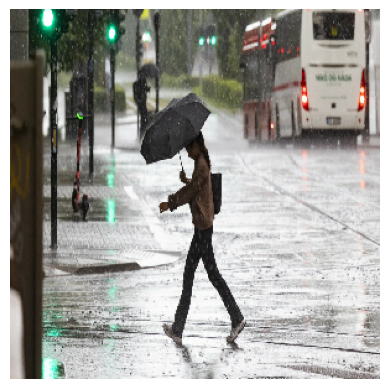

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
Predicted Caption: startseq woman in black jacket is walking in the rain with her umbrella


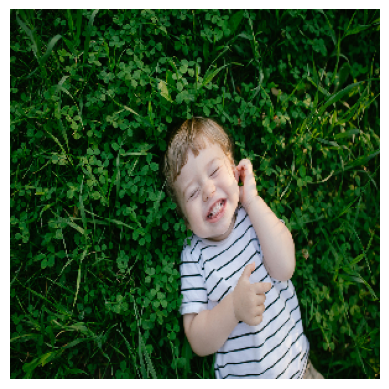

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Predicted Caption: startseq young boy in blue shirt is sitting on the grass


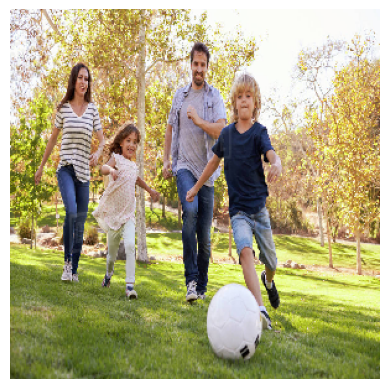

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
Predicted Caption: startseq man in blue shirt is playing soccer


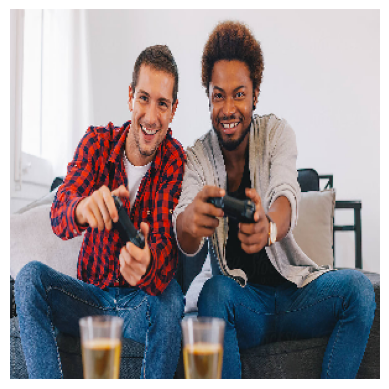

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Predicted Caption: startseq man is sitting on the floor with his hand on his lap


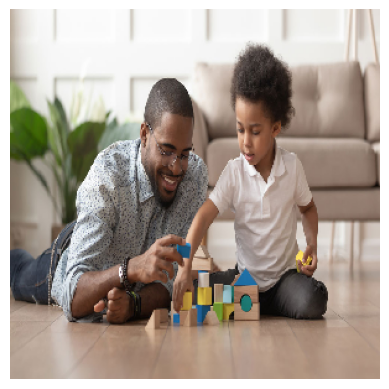

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
Predicted Caption: startseq man is sitting on the floor playing with toy


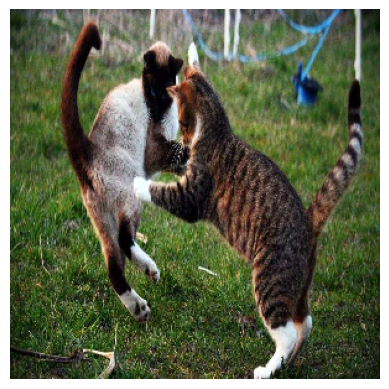

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
Predicted Caption: startseq dog is jumping over the bar


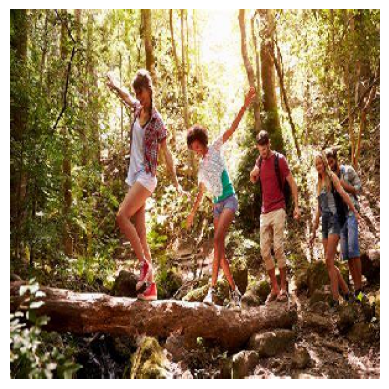

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
Predicted Caption: startseq man in blue shirt and shorts is standing on rock in the middle of the ocean


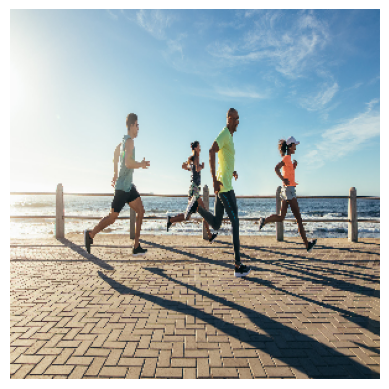

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
Predicted Caption: startseq two people are standing on beach and one of them is holding hands


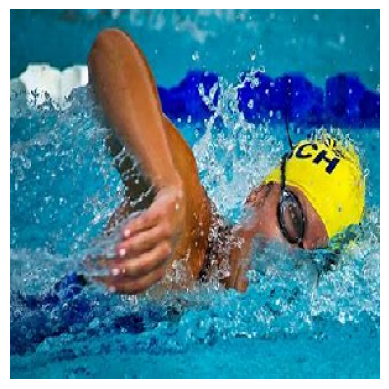

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
Predicted Caption: startseq boy in swimming pool


In [58]:
import os
import glob
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.applications.inception_v3 import preprocess_input
import matplotlib.pyplot as plt

# Đường dẫn đến thư mục chứa hình ảnh mới
test_images_dir = r"D:\Kì 1 2024-2025\Machine Learning\Model Final\Finallll\Test"

# Lấy danh sách tất cả các tệp .jpg trong thư mục
test_images = glob.glob(os.path.join(test_images_dir, '*.jpg'))

# Hàm preprocess ảnh
def preprocess(image_path):
    img = image.load_img(image_path, target_size=(299, 299))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    return x

# Hàm encode ảnh bằng InceptionV3
def encode_image(image_path):
    img = preprocess(image_path)
    feature_vector = model_new.predict(img)
    feature_vector = feature_vector.reshape((1, feature_vector.shape[1]))
    return feature_vector

# Hàm greedySearch (sửa lỗi định nghĩa)
def greedySearch(photo, max_length):
    in_text = 'startseq'
    for i in range(max_length):
        sequence = [wordtoix[w] for w in in_text.split() if w in wordtoix]
        sequence = pad_sequences([sequence], maxlen=max_length)
        yhat = model.predict([photo, sequence], verbose=0)
        yhat = np.argmax(yhat)
        word = ixtoword[yhat]
        if word == 'endseq':
            break
        in_text += ' ' + word
    return in_text

# Thiết lập max_length
max_length = 70

# Dự đoán chú thích cho từng ảnh
for img_path in test_images:
    # Hiển thị ảnh
    img = image.load_img(img_path, target_size=(299, 299))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # Mã hóa ảnh và dự đoán chú thích
    encoded_img = encode_image(img_path)
    caption = greedySearch(encoded_img, max_length)
    print("Predicted Caption:", caption)


In [59]:
print(f"Số lượng đặc trưng mã hóa trong encoding_test: {len(encoding_test)}")


Số lượng đặc trưng mã hóa trong encoding_test: 7357


In [60]:
test_features = load(open(r"D:\Kì 1 2024-2025\Machine Learning\Model Final\Finallll\Encode\encoded_test_images.pkl", "rb"))
print('Photos: test=%d' % len(test_features))

Photos: test=7357


In [62]:
# Load the caption file
def load_doc(filename):
    # open the file as read only
    file = open(filename, 'r')
    # read all text
    text = file.read()
    # close the file
    file.close()
    return text

filename = r"D:\Kì 1 2024-2025\Machine Learning\Model Final\Finallll\Images.token.txt"

doc = load_doc(filename)
print(doc[:300])

1000268201_693b08cb0e.jpg#0	A child in a pink dress is climbing up a set of stairs in an entry way .
1000268201_693b08cb0e.jpg#1	A girl going into a wooden building .
1000268201_693b08cb0e.jpg#2	A little girl climbing into a wooden playhouse .
1000268201_693b08cb0e.jpg#3	A little girl climbing the s


In [63]:
# Lấy id ảnh tương ứng với dữ liệu train, test, dev
def load_set(filename):
    doc = load_doc(filename)
    dataset = list()
    # process line by line
    for line in doc.split('\n'):
        # skip empty lines
        if len(line) < 1:
            continue
        # get the image identifier
        identifier = line.split('.')[0]
        dataset.append(identifier)
    return set(dataset)

# load testing dataset 
filename2 = r"D:\Kì 1 2024-2025\Machine Learning\Model Final\Finallll\Test_Images.txt"
test = load_set(filename2)
print('Dataset: %d' % len(test))

Dataset: 7357


In [64]:
# Thêm 'startseq', 'endseq' cho chuỗi
def load_clean_descriptions(filename, dataset):
    # load document
    doc = load_doc(filename)
    descriptions = dict()
    for line in doc.split('\n'):
        # split line by white space
        tokens = line.split()
        # split id from description
        image_id, image_desc = tokens[0], tokens[1:]
        # skip images not in the set
        if image_id in dataset:
            # create list
            if image_id not in descriptions:
                descriptions[image_id] = list()
            # wrap description in tokens
            desc = 'startseq ' + ' '.join(image_desc) + ' endseq'
            # store
            descriptions[image_id].append(desc)
    return descriptions

test_descriptions = load_clean_descriptions('descriptions.txt', test)
print('Descriptions: test=%d' % len(test_descriptions))

Descriptions: test=7357


In [ ]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import numpy as np

# Hàm để tạo chú thích dự đoán từ mô hình
def generate_caption(model, photo, wordtoix, ixtoword, max_length):
    in_text = 'startseq'
    for i in range(max_length):
        sequence = [wordtoix[w] for w in in_text.split() if w in wordtoix]
        sequence = pad_sequences([sequence], maxlen=max_length)
        yhat = model.predict([photo, sequence], verbose=0)
        yhat = np.argmax(yhat)
        word = ixtoword.get(yhat)
        if word is None:
            break
        in_text += ' ' + word
        if word == 'endseq':
            break
    return in_text.split()[1:-1]  # Loại bỏ 'startseq' và 'endseq'

# Hàm tính điểm BLEU
def evaluate_model_bleu(model, descriptions, photos, wordtoix, ixtoword, max_length):
    smooth = SmoothingFunction().method4
    actual, predicted = list(), list()
    for key, desc_list in descriptions.items():
        y_pred = generate_caption(model, photos[key + '.jpg'].reshape((1, 2048)), wordtoix, ixtoword, max_length)
        references = [desc.split() for desc in desc_list]
        actual.append(references)
        predicted.append(y_pred)
    
    # Tính BLEU-1, BLEU-2, BLEU-3, BLEU-4
    bleu_scores = {"BLEU-1": [], "BLEU-2": [], "BLEU-3": [], "BLEU-4": []}
    for ref, pred in zip(actual, predicted):
        bleu_scores["BLEU-1"].append(sentence_bleu(ref, pred, weights=(1, 0, 0, 0), smoothing_function=smooth))
        bleu_scores["BLEU-2"].append(sentence_bleu(ref, pred, weights=(0.5, 0.5, 0, 0), smoothing_function=smooth))
        bleu_scores["BLEU-3"].append(sentence_bleu(ref, pred, weights=(0.33, 0.33, 0.33, 0), smoothing_function=smooth))
        bleu_scores["BLEU-4"].append(sentence_bleu(ref, pred, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth))
    
    # Trung bình điểm BLEU cho toàn bộ tập
    for key in bleu_scores:
        bleu_scores[key] = np.mean(bleu_scores[key])
    return bleu_scores

# Đánh giá trên tập kiểm tra
bleu_scores = evaluate_model_bleu(
    model=model,
    descriptions=test_descriptions,  
    photos=test_features,           
    wordtoix=wordtoix,
    ixtoword=ixtoword,
    max_length=max_length
)

# Hiển thị kết quả
print("BLEU Scores:")
for k, v in bleu_scores.items():
    print(f"{k}: {v:.4f}")


BLEU Scores:
BLEU-1: 0.4426
BLEU-2: 0.2540
BLEU-3: 0.1574
BLEU-4: 0.1009
